# Born in Simulation: Visual Domain Randomization for Sim-to-Real Transfer
## Seminar in AI — 340.910 | JKU Linz 2026S
### Saqib Ali Khan — K12343661 | Team: Backpropagated Learners

---

**Paper:** Born in Simulation: How Digital Twins Bring Physical AI to Life
**Topic:** Simulation and Sim-to-Real Transfer
**Grounding:** Tobin et al. 2017 — Domain Randomization for Transferring Deep Neural
Networks from Simulation to the Real World (IEEE/RSJ IROS)

**Dataset:** YCB Object and Model Set (Calli et al. 2015)

---

## Research Question

> *"How does the diversity of visual domain randomization affect sim-to-real transfer accuracy for object recognition — is there a threshold beyond which additional texture diversity yields diminishing returns — and what changes in the neural network's learned representations as texture diversity increases?"*

## Experiment Design

We train **6 ResNet-18 classifiers**, one per texture diversity level:

| Model | Level | Description |
|-------|-------|-------------|
| Model 0 | 0 | No randomization — fixed grey floor, fixed red object |
| Model 1 | 10 | 10 unique colour combinations, cycling |
| Model 2 | 100 | 100 unique colour combinations |
| Model 3 | 500 | 500 unique colour combinations |
| Model 4 | 1,000 | 1,000 unique colour combinations |
| Model 5 | 5,000 | Maximum diversity |

**Task:** 5-class recognition — given a 224×224 image, predict which YCB object is shown.
**Train:** 15,000 synthetic PyBullet renders (500 images × 5 classes × 6 levels).
**Test:** 6,000 real YCB RGB photographs (1,200 × 5 classes) — never seen during training.
**Metric:** Top-1 classification accuracy on real images.

## Cell 1 — Imports

In [5]:
# ── Standard library ──────────────────────────────────────────────────
import os, csv, random, time
from pathlib import Path

# ── Numerical / image ─────────────────────────────────────────────────
import numpy as np
from PIL import Image
import cv2

# ── PyTorch ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# ── Visualisation ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Simulation ────────────────────────────────────────────────────────
import pybullet as p
import pybullet_data

# ── Progress ──────────────────────────────────────────────────────────
from tqdm.auto import tqdm

# ── GPU check ─────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM   : 6.4 GB
PyTorch: 2.2.1+cu121


## Cell 2 — Configuration

All paths and hyperparameters in one place.
**Only `BASE_DIR` needs updating if your folder is in a different location.**

In [6]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment")
MESH_DIR    = BASE_DIR / "3D mesh for simulation (16k )"
RGB_DIR     = BASE_DIR / "RGB images for testing"
SYNTH_DIR   = BASE_DIR / "synthetic_images"
MODELS_DIR  = BASE_DIR / "trained_models"
RESULTS_DIR = BASE_DIR / "results"

for folder in [SYNTH_DIR, MODELS_DIR, RESULTS_DIR]:
    folder.mkdir(exist_ok=True)

# ── YCB objects (5 classes) ─────────────────────────────────────────────
OBJECTS = [
    "025_mug",
    "006_mustard_bottle",
    "035_power_drill",
    "024_bowl",
    "021_bleach_cleanser",
]
CLASS_MAP = {i: obj for i, obj in enumerate(OBJECTS)}  # 0 → "025_mug", etc.

# ── Texture diversity levels ─────────────────────────────────────────────
# 0 = no randomization baseline; 10–5000 = increasing colour diversity
TEXTURE_LEVELS = [10, 100, 500, 1000, 5000]
ALL_LEVELS     = [0] + TEXTURE_LEVELS   # [0, 10, 100, 500, 1000, 5000]

# ── Simulation dataset ───────────────────────────────────────────────────
IMAGES_PER_CLASS = 500   # synthetic images per class per level

# ── Model / training ─────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 1e-4

# ── Verify ──────────────────────────────────────────────────────────────
print("Folder check:")
print(f"  Mesh dir : {'OK' if MESH_DIR.exists()  else 'MISSING'}  {MESH_DIR}")
print(f"  RGB dir  : {'OK' if RGB_DIR.exists()   else 'MISSING'}  {RGB_DIR}")
print(f"  Outputs  : synthetic_images / trained_models / results created OK")

print("\nMesh files:")
for obj in OBJECTS:
    mesh = MESH_DIR / obj / "google_16k" / "textured.obj"
    print(f"  {obj}: {'OK' if mesh.exists() else 'MISSING'}")

print("\nRGB test folders:")
for obj in OBJECTS:
    obj_dir = RGB_DIR / obj
    if obj_dir.exists():
        imgs = list(obj_dir.rglob("*.jpg")) + list(obj_dir.rglob("*.JPG"))
        print(f"  {obj}: {len(imgs)} images")
    else:
        print(f"  {obj}: MISSING")

Folder check:
  Mesh dir : OK  C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\3D mesh for simulation (16k )
  RGB dir  : OK  C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\RGB images for testing
  Outputs  : synthetic_images / trained_models / results created OK

Mesh files:
  025_mug: OK
  006_mustard_bottle: OK
  035_power_drill: OK
  024_bowl: OK
  021_bleach_cleanser: OK

RGB test folders:
  025_mug: 1200 images
  006_mustard_bottle: 1200 images
  035_power_drill: 1200 images
  024_bowl: 1200 images
  021_bleach_cleanser: 1200 images


## Cell 3 — PyBullet Domain Randomized Renderer

This class renders YCB objects in PyBullet's headless mode with **Visual Domain
Randomization** following Tobin et al. 2017.

**What changes per render (when `randomize=True`):**
- Object colour — random RGBA
- Floor colour — random RGBA
- Camera — random distance (0.35–0.75 m), yaw (0–360°), pitch (−70° to −15°)
- Distractors — 0–4 random coloured boxes placed in the scene

**When `randomize=False` (Model 0 baseline):**
Every render is identical: grey floor, red object, fixed camera angle.
The model learns to identify objects by colour rather than shape —
which is exactly why it fails on real images.

The cell ends with a 4-image smoke test so you can confirm the renderer
works before running the full generation loop.

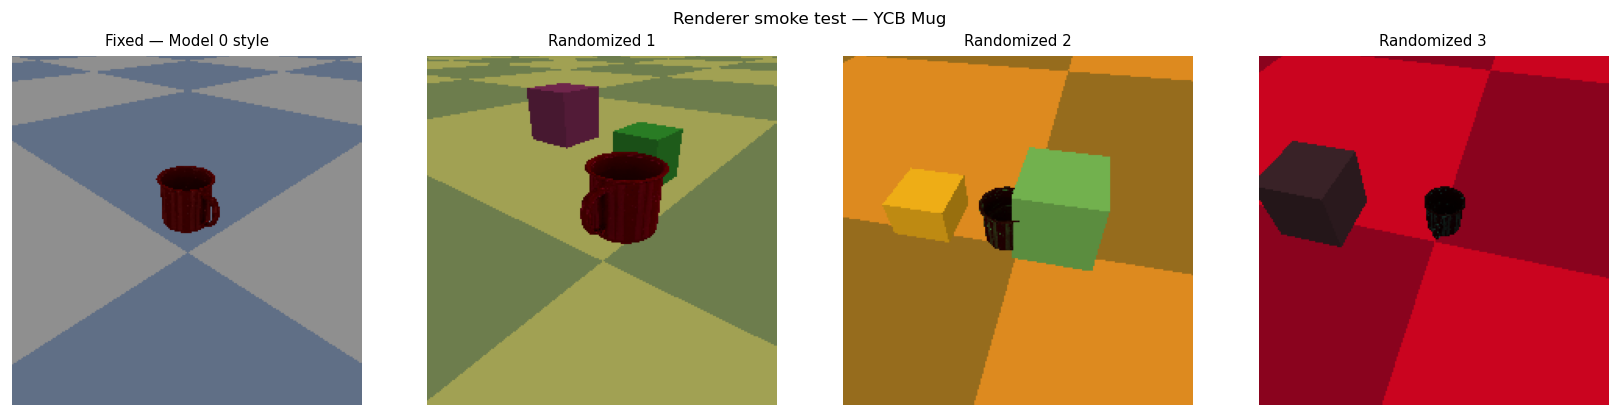

Renderer OK


In [7]:
class DomainRandomizedRenderer:
    """
    Renders YCB .obj meshes in PyBullet with visual domain randomization.
    Ref: Tobin et al. 2017 — Domain Randomization for Transferring Deep
         Neural Networks from Simulation to the Real World.
    """

    def __init__(self, img_size=224):
        self.img_size = img_size
        self.physics_client = None

    def connect(self):
        """Open a headless PyBullet session."""
        if self.physics_client is not None:
            try:
                p.disconnect(self.physics_client)
            except Exception:
                pass
        self.physics_client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -9.81)

    def disconnect(self):
        if self.physics_client is not None:
            try:
                p.disconnect(self.physics_client)
            except Exception:
                pass
            self.physics_client = None

    def _random_color(self):
        return [random.random(), random.random(), random.random(), 1.0]

    def render_object(self, mesh_path, randomize=True,
                      distance=0.5, yaw=45, pitch=-35):
        """
        Render one image of a YCB object.

        Args:
            mesh_path : Path to .obj file
            randomize : True  = random colours, camera, distractors
                        False = fixed neutral appearance (Model 0 baseline)
        Returns:
            PIL Image (IMG_SIZE x IMG_SIZE, RGB), or None on mesh error.
        """
        p.resetSimulation()
        p.setGravity(0, 0, -9.81)

        # Floor
        plane_id    = p.loadURDF("plane.urdf")
        floor_color = self._random_color() if randomize else [0.6, 0.6, 0.6, 1.0]
        p.changeVisualShape(plane_id, -1, rgbaColor=floor_color)

        # Main object
        try:
            vis_id = p.createVisualShape(
                p.GEOM_MESH, fileName=str(mesh_path), meshScale=[1, 1, 1],
                rgbaColor=self._random_color() if randomize else [0.8, 0.2, 0.2, 1.0]
            )
            col_id = p.createCollisionShape(
                p.GEOM_MESH, fileName=str(mesh_path), meshScale=[1, 1, 1]
            )
            obj_id = p.createMultiBody(
                baseMass=0.1,
                baseCollisionShapeIndex=col_id,
                baseVisualShapeIndex=vis_id,
                basePosition=[0, 0, 0.05]
            )
        except Exception as e:
            print(f"Mesh load error ({mesh_path.name}): {e}")
            return None

        if randomize:
            p.changeVisualShape(obj_id, -1, rgbaColor=self._random_color())

        # Distractor objects (coloured boxes — Tobin et al. style)
        if randomize:
            for _ in range(random.randint(0, 4)):
                pos  = [random.uniform(-0.3, 0.3),
                        random.uniform(-0.3, 0.3),
                        random.uniform(0.02, 0.15)]
                size = random.uniform(0.02, 0.08)
                vis  = p.createVisualShape(
                    p.GEOM_BOX, halfExtents=[size]*3,
                    rgbaColor=self._random_color()
                )
                col  = p.createCollisionShape(p.GEOM_BOX, halfExtents=[size]*3)
                p.createMultiBody(0, col, vis, pos)

        # Camera
        if randomize:
            distance = random.uniform(0.35, 0.75)
            yaw      = random.uniform(0, 360)
            pitch    = random.uniform(-70, -15)

        view_mat = p.computeViewMatrixFromYawPitchRoll(
            cameraTargetPosition=[0, 0, 0.05],
            distance=distance, yaw=yaw, pitch=pitch,
            roll=0, upAxisIndex=2
        )
        proj_mat = p.computeProjectionMatrixFOV(
            fov=60, aspect=1.0, nearVal=0.01, farVal=10.0
        )
        _, _, rgb, _, _ = p.getCameraImage(
            width=self.img_size, height=self.img_size,
            viewMatrix=view_mat, projectionMatrix=proj_mat,
            renderer=p.ER_TINY_RENDERER
        )
        arr = np.array(rgb, dtype=np.uint8).reshape(
            self.img_size, self.img_size, 4
        )
        return Image.fromarray(arr[:, :, :3])


def get_mesh_path(obj_name):
    """Return the confirmed textured.obj path for a YCB object."""
    return MESH_DIR / obj_name / "google_16k" / "textured.obj"


def get_level_name(texture_level):
    """Integer texture level -> canonical folder/filename string."""
    return ("no_randomization" if texture_level == 0
            else f"textures_{texture_level:05d}")


# ── Smoke test ──────────────────────────────────────────────────────────
renderer = DomainRandomizedRenderer(img_size=IMG_SIZE)
renderer.connect()
mug_mesh = get_mesh_path("025_mug")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (title, rand) in zip(axes, [
    ("Fixed — Model 0 style", False),
    ("Randomized 1", True),
    ("Randomized 2", True),
    ("Randomized 3", True),
]):
    ax.imshow(np.array(renderer.render_object(mug_mesh, randomize=rand)))
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Renderer smoke test — YCB Mug", fontsize=10)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "renderer_test.png"), dpi=100, bbox_inches="tight")
plt.show()
print("Renderer OK")

## Cell 4 — Synthetic Dataset Generation

### Design

**Multi-class, no negative images.**
Every training image shows a YCB object. Label = which object (integer 0–4).

**Folder structure:**

```
synthetic_images/
    no_randomization/          <- level 0 (baseline)
        025_mug/               500 images — class 0
        006_mustard_bottle/    500 images — class 1
        035_power_drill/       500 images — class 2
        024_bowl/              500 images — class 3
        021_bleach_cleanser/   500 images — class 4
    textures_00010/            <- level 1
        ... same 5 subfolders
    textures_05000/            <- level 5
        ... same 5 subfolders
```

**Diversity control — seed cycling.**
For object index j and image index i at level N:

```
cycle_seed = 42 + j × 100,000 + (i % N)
```

- `N = 10`   → only 10 unique seeds → 10 distinct colour combos, repeating
- `N = 5000` → i < 500 < 5000, so `i % 5000 = i` → every image has a unique seed

The `j × 100,000` offset ensures that mug (j=0) and bowl (j=3) never share the
same background colour at the same image index.

**Idempotent:** the loop checks for existing images before generating.
You can safely interrupt and resume — completed jobs are skipped.

In [10]:
def generate_dataset(renderer, obj_name, texture_level,
                     images_per_class=500, seed=42):
    """
    Generate synthetic training images for one (object, texture_level) pair.

    Output: synthetic_images/{level_name}/{obj_name}/{i:04d}.png
    Label for training = OBJECTS.index(obj_name)
    """
    mesh_path  = get_mesh_path(obj_name)
    level_name = get_level_name(texture_level)
    obj_idx    = OBJECTS.index(obj_name)  # 0..4 — per-object seed offset

    obj_dir = SYNTH_DIR / level_name / obj_name
    obj_dir.mkdir(parents=True, exist_ok=True)

    existing = len(list(obj_dir.glob("*.png")))
    if existing >= images_per_class:
        print(f"  {obj_name:35s} / {level_name}: complete — skipping")
        return

    print(f"  {obj_name:35s} / {level_name} ...", end="", flush=True)

    for i in range(images_per_class):
        img_path = obj_dir / f"{i:04d}.png"
        if img_path.exists():
            continue

        if texture_level == 0:
            img = renderer.render_object(mesh_path, randomize=False)
        else:
            cycle_seed = seed + obj_idx * 100_000 + (i % texture_level)
            random.seed(cycle_seed)
            np.random.seed(cycle_seed)
            img = renderer.render_object(mesh_path, randomize=True)

        if img is not None:
            img.save(str(img_path))

    count = len(list(obj_dir.glob("*.png")))
    print(f" {count} images OK")


# ── Generation loop — 6 levels x 5 objects = 30 jobs, 15,000 images ──
TOTAL_JOBS = len(ALL_LEVELS) * len(OBJECTS)

print("=" * 66)
print(f"  GENERATING SYNTHETIC TRAINING DATASET")
print(f"  {len(ALL_LEVELS)} levels x {len(OBJECTS)} objects x {IMAGES_PER_CLASS} images"
      f" = {TOTAL_JOBS * IMAGES_PER_CLASS:,} total images")
print("=" * 66)

# Reconnect renderer fresh for the generation run
renderer = DomainRandomizedRenderer(img_size=IMG_SIZE)
renderer.connect()

t0        = time.time()
completed = 0
skipped   = 0
errors    = []

level_bar = tqdm(ALL_LEVELS, desc="Texture levels", unit="level", position=0)

for level in level_bar:
    label = get_level_name(level)
    level_bar.set_description(f"Level  {label}")

    obj_bar = tqdm(OBJECTS, desc="  Objects", unit="obj", position=1, leave=False)
    for obj in obj_bar:
        obj_bar.set_description(f"  {obj}")

        jobs_done = completed + skipped
        if jobs_done > 0:
            eta_s   = (time.time() - t0) / jobs_done * (TOTAL_JOBS - jobs_done)
            eta_str = f"{eta_s/60:.1f} min" if eta_s >= 60 else f"{eta_s:.0f} s"
        else:
            eta_str = "—"
        obj_bar.set_postfix(job=f"{jobs_done+1:02d}/{TOTAL_JOBS}", ETA=eta_str)

        obj_dir    = SYNTH_DIR / label / obj
        n_existing = len(list(obj_dir.glob("*.png"))) if obj_dir.exists() else 0
        if n_existing >= IMAGES_PER_CLASS:
            skipped += 1
            continue

        try:
            generate_dataset(renderer, obj, level, IMAGES_PER_CLASS, seed=42)
            completed += 1
        except Exception as exc:
            err_msg = f"level={label}, obj={obj} -> {exc}"
            errors.append(err_msg)
            tqdm.write(f"  ERROR: {err_msg}")

    obj_bar.close()

renderer.disconnect()
elapsed = time.time() - t0
print(f"\nDone in {elapsed/60:.1f} min  |  "
      f"Generated: {completed}  Skipped: {skipped}  Errors: {len(errors)}")

# ── Summary table ────────────────────────────────────────────────────
print(f"\n  {'Level':<26} {'Images':>8}  Status")
print(f"  {'-'*26} {'-'*8}  {'-'*12}")
all_ok = True
for level in ALL_LEVELS:
    lname    = get_level_name(level)
    expected = len(OBJECTS) * IMAGES_PER_CLASS
    total    = sum(
        len(list((SYNTH_DIR / lname / obj).glob("*.png")))
        for obj in OBJECTS if (SYNTH_DIR / lname / obj).exists()
    )
    ok      = (total == expected)
    all_ok  = all_ok and ok
    print(f"  {lname:<26} {total:>8,}  {'OK' if ok else f'INCOMPLETE — expected {expected}'}")

if all_ok and not errors:
    print("\n  All 15,000 training images ready")
if errors:
    for e in errors:
        print(f"  ERROR: {e}")

  GENERATING SYNTHETIC TRAINING DATASET
  6 levels x 5 objects x 500 images = 15,000 total images


Texture levels:   0%|          | 0/6 [00:00<?, ?level/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]


Done in 0.0 min  |  Generated: 0  Skipped: 30  Errors: 0

  Level                        Images  Status
  -------------------------- --------  ------------
  no_randomization              2,500  OK
  textures_00010                2,500  OK
  textures_00100                2,500  OK
  textures_00500                2,500  OK
  textures_01000                2,500  OK
  textures_05000                2,500  OK

  All 15,000 training images ready


### Dataset Verification

5 objects × 3 diversity levels sampled at image index 50.
Level 0 column should look identical row-to-row for the same object
(same fixed render). Level 5000 column should show distinct colour schemes
(different unique seeds).

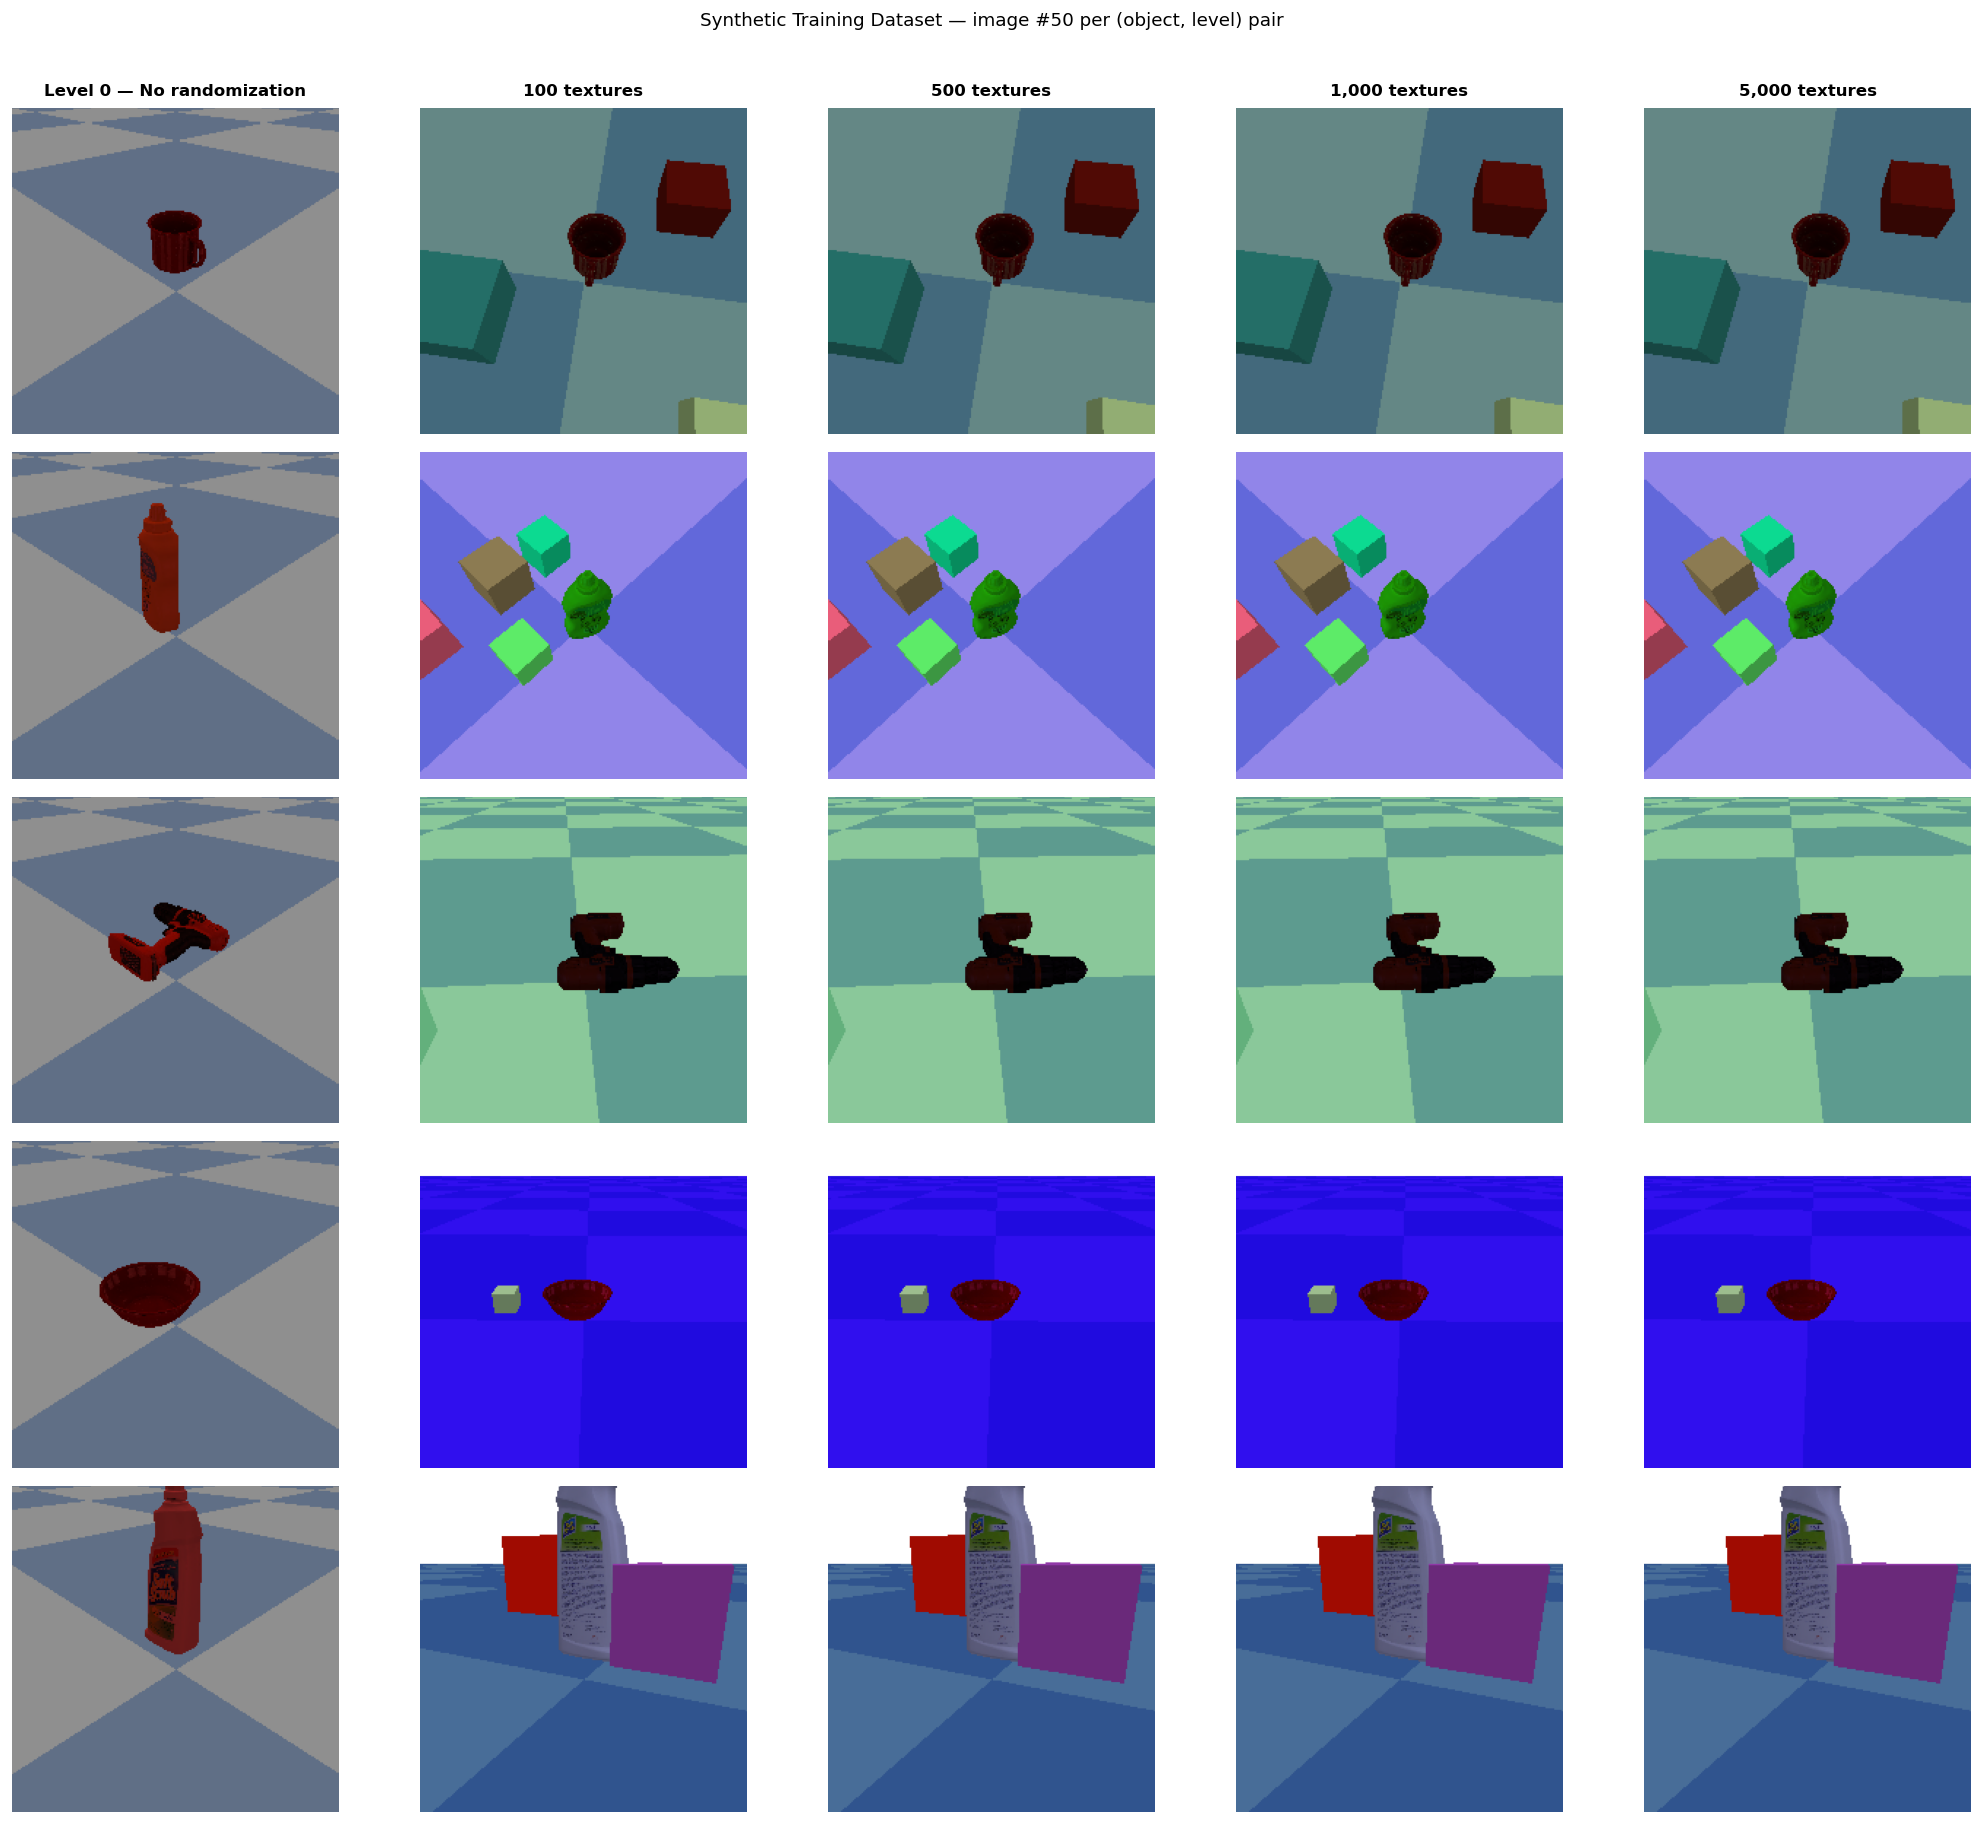

Verification grid saved -> results/dataset_verification.png


In [11]:
SHOW_LEVELS  = [0, 100, 500, 1000, 5000]
SHOW_IDX     = 50

fig, axes = plt.subplots(
    len(OBJECTS), len(SHOW_LEVELS),
    figsize=(3.5 * len(SHOW_LEVELS), 3 * len(OBJECTS))
)

for col, level in enumerate(SHOW_LEVELS):
    label = get_level_name(level)
    title = "Level 0 — No randomization" if level == 0 else f"{level:,} textures"
    axes[0, col].set_title(title, fontsize=10, pad=7, fontweight="bold")

    for row, obj_name in enumerate(OBJECTS):
        obj_dir = SYNTH_DIR / label / obj_name
        imgs    = sorted(obj_dir.glob("*.png")) if obj_dir.exists() else []
        ax      = axes[row, col]

        if not imgs:
            ax.text(0.5, 0.5, "No images", ha="center", va="center",
                    transform=ax.transAxes, color="red")
        else:
            ax.imshow(np.array(Image.open(imgs[min(SHOW_IDX, len(imgs)-1)])))

        ax.axis("off")
        if col == 0:
            short = obj_name.split("_", 1)[1].replace("_", " ")
            ax.set_ylabel(f"Class {row}\n{short}",
                          fontsize=8, rotation=90, labelpad=6, va="center")

plt.suptitle("Synthetic Training Dataset — image #50 per (object, level) pair",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "dataset_verification.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Verification grid saved -> results/dataset_verification.png")

## Cell 5 — PyTorch Datasets and Transforms

Two dataset classes share the same label scheme:
`OBJECTS.index(obj_name)` → integer 0–4.

**`SyntheticDataset(texture_level)`** — loads simulated training images
from `synthetic_images/{level_name}/{obj_name}/`.

**`RealYCBDataset()`** — loads real RGB test photographs from
`RGB images for testing/{obj_name}/`. These images are **never used during training**.

**Transform choices:**
- Training: resize → random horizontal flip → tensor → ImageNet normalisation.
  *No colour jitter* — the simulation's domain randomisation already provides colour
  diversity. Adding jitter on top would double-count it.
- Test: resize → tensor → normalisation only (deterministic — no augmentation).

In [12]:
# ── Transforms ──────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),   # ImageNet statistics
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


class SyntheticDataset(Dataset):
    """Simulated training images for one texture level. Label = 0..4."""

    def __init__(self, texture_level, transform=None):
        self.transform = transform
        self.samples   = []
        level_name     = get_level_name(texture_level)
        for class_idx, obj_name in enumerate(OBJECTS):
            obj_dir = SYNTH_DIR / level_name / obj_name
            if not obj_dir.exists():
                print(f"  WARNING — missing: {obj_dir}")
                continue
            for img_path in sorted(obj_dir.glob("*.png")):
                self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class RealYCBDataset(Dataset):
    """Real YCB RGB test images. Label = 0..4. Never used during training."""

    def __init__(self, transform=None):
        self.transform = transform
        self.samples   = []
        for class_idx, obj_name in enumerate(OBJECTS):
            obj_dir = RGB_DIR / obj_name
            if not obj_dir.exists():
                print(f"  WARNING — missing: {obj_dir}")
                continue
            imgs = (list(obj_dir.rglob("*.jpg"))  +
                    list(obj_dir.rglob("*.JPG"))  +
                    list(obj_dir.rglob("*.jpeg")) +
                    list(obj_dir.rglob("*.png")))
            for p_ in sorted(set(imgs)):
                self.samples.append((p_, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Sanity check ────────────────────────────────────────────────────────
print(f"Class map: {CLASS_MAP}\n")

print("Synthetic training sets:")
for level in ALL_LEVELS:
    ds       = SyntheticDataset(level)
    expected = len(OBJECTS) * IMAGES_PER_CLASS
    flag     = "OK" if len(ds) == expected else f"WARNING — expected {expected}"
    print(f"  {get_level_name(level):<26}: {len(ds):>5} images  {flag}")

real_ds = RealYCBDataset()
print(f"\nReal YCB test set: {len(real_ds)} images")
for i, obj in enumerate(OBJECTS):
    count = sum(1 for _, l in real_ds.samples if l == i)
    print(f"  Class {i} — {obj}: {count} images")

Class map: {0: '025_mug', 1: '006_mustard_bottle', 2: '035_power_drill', 3: '024_bowl', 4: '021_bleach_cleanser'}

Synthetic training sets:
  no_randomization          :  2500 images  OK
  textures_00010            :  2500 images  OK
  textures_00100            :  2500 images  OK
  textures_00500            :  2500 images  OK
  textures_01000            :  2500 images  OK
  textures_05000            :  2500 images  OK

Real YCB test set: 3000 images
  Class 0 — 025_mug: 600 images
  Class 1 — 006_mustard_bottle: 600 images
  Class 2 — 035_power_drill: 600 images
  Class 3 — 024_bowl: 600 images
  Class 4 — 021_bleach_cleanser: 600 images


## Cell 6 — ResNet-18 Multi-class Classifier — Training

**Architecture:** Pretrained ResNet-18 (ImageNet weights), final FC replaced with
`Linear(512 → 5)`. We fine-tune all layers — the pretrained weights provide strong
low-level edge and texture features as a starting point.

**Loss:** `CrossEntropyLoss` — standard for multi-class classification
(applies log-softmax and negative log-likelihood internally).

**Optimiser:** Adam, lr=1e-4.
`ReduceLROnPlateau` halves the learning rate if training loss
stalls for 2 epochs in a row.

**What to expect:**
- Model 0 achieves high training accuracy quickly — it memorises the fixed red colour.
- Models 1–5 train more slowly — colour cues are randomised away, so the model must
  learn geometry. Training accuracy may be lower, but real-world accuracy will be higher.

Each checkpoint is saved as `trained_models/model_{level_name}.pth` with the full
training history embedded. Re-running this cell skips models that are already saved.

In [13]:
def build_model(num_classes=5):
    """ResNet-18 pretrained on ImageNet, FC replaced: Linear(512 -> num_classes)."""
    model    = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def train_one_level(texture_level, epochs=EPOCHS, verbose=True):
    """
    Train one ResNet-18 on synthetic images for texture_level.
    Saves to trained_models/model_{level_name}.pth.
    Returns history {'loss': [...], 'acc': [...]} — loaded from disk if exists.
    """
    level_name = get_level_name(texture_level)
    model_path = MODELS_DIR / f"model_{level_name}.pth"

    if model_path.exists():
        ckpt = torch.load(model_path, map_location="cpu")
        if verbose:
            acc = ckpt["history"]["acc"][-1]
            print(f"  [{level_name}] checkpoint found "
                  f"(final train acc: {acc:.1f}%) — skipping")
        return ckpt.get("history")

    if verbose:
        print(f"\n{'─'*58}")
        print(f"  Training : {level_name}")
        print(f"  Data     : {len(OBJECTS)*IMAGES_PER_CLASS} images "
              f"({IMAGES_PER_CLASS} per class)")
        print(f"{'─'*58}")

    dataset   = SyntheticDataset(texture_level, transform=train_transform)
    loader    = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=0, pin_memory=True)
    model     = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2, verbose=False
    )
    history = {"loss": [], "acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0

        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * imgs.size(0)
            _, preds  = logits.max(1)
            total    += labels.size(0)
            correct  += preds.eq(labels).sum().item()

        ep_loss = run_loss / total
        ep_acc  = 100.0 * correct / total
        history["loss"].append(round(ep_loss, 5))
        history["acc"].append(round(ep_acc, 2))
        scheduler.step(ep_loss)

        if verbose:
            print(f"  Epoch {epoch:02d}/{epochs}  "
                  f"loss={ep_loss:.4f}  train_acc={ep_acc:5.1f}%")

    torch.save({
        "texture_level": texture_level,
        "level_name"   : level_name,
        "model_state"  : model.state_dict(),
        "history"      : history,
        "objects"      : OBJECTS,
        "num_classes"  : len(OBJECTS),
    }, model_path)

    if verbose:
        print(f"  Saved -> {model_path.name}")
    return history


# ── Train all 6 models ─────────────────────────────────────────────────
print("=" * 58)
print("  TRAINING — 6 ResNet-18 models (5-class each)")
print("=" * 58)

all_histories = {}
t_total       = time.time()

for level in ALL_LEVELS:
    t0      = time.time()
    history = train_one_level(level, epochs=EPOCHS, verbose=True)
    if history:
        all_histories[level] = history
    elapsed = time.time() - t0
    if elapsed > 5:
        print(f"  -> {elapsed/60:.1f} min\n")

print(f"\n{'='*58}")
print(f"  All 6 models ready — {(time.time()-t_total)/60:.1f} min total")
print(f"{'='*58}")

print(f"\n  {'Level':<26}  {'Train acc':>9}  Loss")
print(f"  {'-'*26}  {'-'*9}  {'-'*6}")
for level in ALL_LEVELS:
    name  = get_level_name(level)
    fpath = MODELS_DIR / f"model_{name}.pth"
    if fpath.exists():
        ckpt = torch.load(fpath, map_location="cpu")
        acc  = ckpt["history"]["acc"][-1]
        loss = ckpt["history"]["loss"][-1]
        print(f"  {name:<26}  {acc:>8.1f}%  {loss:.4f}")

  TRAINING — 6 ResNet-18 models (5-class each)
  [no_randomization] checkpoint found (final train acc: 100.0%) — skipping
  [textures_00010] checkpoint found (final train acc: 100.0%) — skipping
  [textures_00100] checkpoint found (final train acc: 100.0%) — skipping
  [textures_00500] checkpoint found (final train acc: 99.9%) — skipping
  [textures_01000] checkpoint found (final train acc: 99.2%) — skipping
  [textures_05000] checkpoint found (final train acc: 99.8%) — skipping

  All 6 models ready — 0.0 min total

  Level                       Train acc  Loss
  --------------------------  ---------  ------
  no_randomization               100.0%  0.0001
  textures_00010                 100.0%  0.0041
  textures_00100                 100.0%  0.0019
  textures_00500                  99.9%  0.0060
  textures_01000                  99.2%  0.0208
  textures_05000                  99.8%  0.0094


## Cell 7 — Evaluation on Real YCB Images

We load each of the 6 saved models and run inference on the
**real YCB RGB test images** — photographs the models have never seen.

**Metric:** Top-1 accuracy — percentage of real images where
the model's highest-confidence prediction matches the true object class.

**Why this is hard:** Training images are flat-coloured simulation renders
with simple lighting. Test images are real photographs with natural shadows,
photographic textures, and background clutter. The gap between them is the
domain gap — and closing it is the entire point of domain randomisation.

In [14]:
def evaluate_model(texture_level):
    """
    Load saved model, evaluate on real YCB test images.
    Returns (overall_accuracy: float, per_class: dict{obj_name: float}).
    """
    level_name = get_level_name(texture_level)
    model_path = MODELS_DIR / f"model_{level_name}.pth"

    if not model_path.exists():
        print(f"  WARNING — no checkpoint for {level_name}")
        return None, None

    ckpt  = torch.load(model_path, map_location=device)
    model = build_model()
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    loader = DataLoader(
        RealYCBDataset(transform=test_transform),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            _, preds = model(imgs.to(device)).max(1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    overall   = 100.0 * (all_preds == all_labels).mean()
    per_class = {
        obj: 100.0 * (all_preds[all_labels == i] == i).mean()
        for i, obj in enumerate(OBJECTS)
        if (all_labels == i).sum() > 0
    }
    return float(overall), per_class


# ── Evaluate all 6 models ───────────────────────────────────────────────
print("=" * 66)
print("  EVALUATION — Real YCB Test Images")
print("=" * 66)

results = {}
for level in ALL_LEVELS:
    name              = get_level_name(level)
    overall, per_class = evaluate_model(level)
    if overall is not None:
        results[level] = {"overall": overall, "per_class": per_class}
        pc_str = "  ".join(f"{per_class[o]:.0f}%" for o in OBJECTS)
        print(f"  {name:<26}  overall={overall:5.1f}%  per-class: {pc_str}")

# Summary table
short_names = [o.split("_", 1)[1].replace("_", " ")[:8] for o in OBJECTS]
hdr         = "  ".join(f"{n:>8}" for n in short_names)
print(f"\n  {'Level':<26}  {'Overall':>7}  {hdr}")
print(f"  {'-'*26}  {'-'*7}  {'  '.join(['-'*8]*len(OBJECTS))}")
for level in ALL_LEVELS:
    name = get_level_name(level)
    if level in results:
        r   = results[level]
        cls = "  ".join(f"{r['per_class'].get(o,0):>7.1f}%" for o in OBJECTS)
        print(f"  {name:<26}  {r['overall']:>6.1f}%  {cls}")

# Save CSV
csv_path = RESULTS_DIR / "accuracy_results.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["texture_level", "level_name", "overall_accuracy"] + OBJECTS)
    for level in ALL_LEVELS:
        name = get_level_name(level)
        if level in results:
            r = results[level]
            writer.writerow(
                [level, name, round(r["overall"], 2)] +
                [round(r["per_class"].get(o, 0), 2) for o in OBJECTS]
            )
print(f"\n  Results saved -> {csv_path}")

  EVALUATION — Real YCB Test Images
  no_randomization            overall=  4.1%  per-class: 0%  0%  11%  10%  0%
  textures_00010              overall= 29.6%  per-class: 0%  0%  0%  67%  81%
  textures_00100              overall= 38.2%  per-class: 0%  50%  52%  0%  88%
  textures_00500              overall= 47.9%  per-class: 12%  34%  98%  26%  71%
  textures_01000              overall= 48.4%  per-class: 10%  48%  91%  3%  89%
  textures_05000              overall= 35.5%  per-class: 18%  16%  44%  0%  99%

  Level                       Overall       mug  mustard   power dr      bowl  bleach c
  --------------------------  -------  --------  --------  --------  --------  --------
  no_randomization               4.1%      0.0%      0.0%     10.7%     10.0%      0.0%
  textures_00010                29.6%      0.0%      0.0%      0.0%     66.8%     81.0%
  textures_00100                38.2%      0.2%     50.3%     52.0%      0.2%     88.5%
  textures_00500                47.9%     11.8%

## Cell 8 — Accuracy vs Texture Diversity Curve

**Central quantitative result of the paper.**

- X-axis: texture diversity level
- Y-axis: top-1 accuracy on real YCB images (%)
- Dashed reference line: 20% = random chance for 5 classes

Top panel — overall accuracy across all 5 objects combined.
Bottom panel — per-class breakdown, which reveals whether
some objects benefit more from diversity than others.

The expected shape is a **rising curve that plateaus** —
the Tobin et al. finding that diversity helps transfer, up to
a point of diminishing returns.

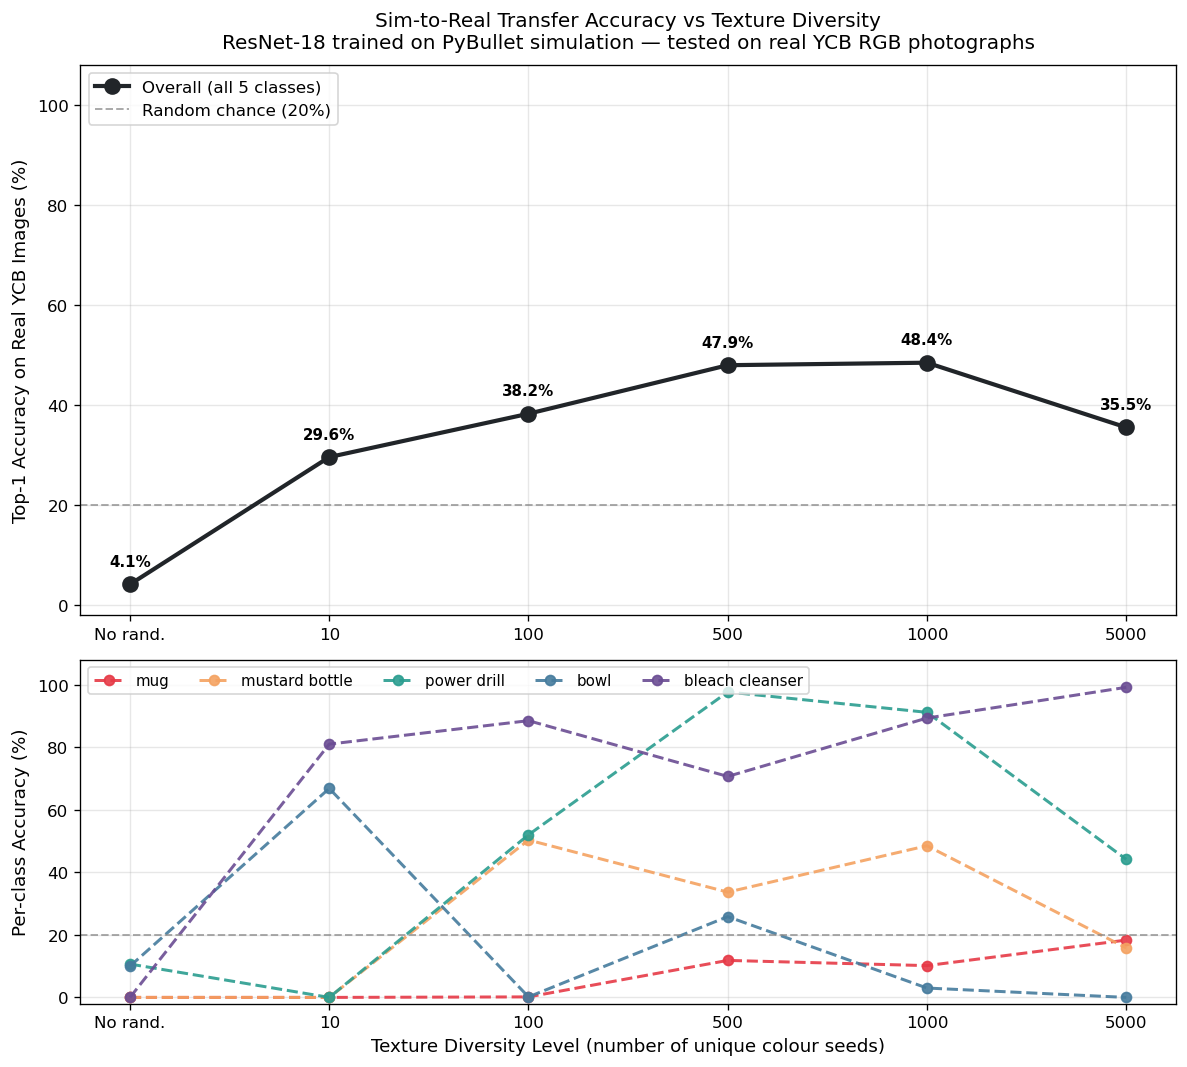

Figure saved -> C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\results\accuracy_vs_diversity.png


In [15]:
OBJ_COLORS = {
    OBJECTS[0]: "#E63946",  # mug     — red
    OBJECTS[1]: "#F4A261",  # mustard — orange
    OBJECTS[2]: "#2A9D8F",  # drill   — teal
    OBJECTS[3]: "#457B9D",  # bowl    — steel blue
    OBJECTS[4]: "#6A4C93",  # bleach  — purple
}

x_pos   = list(range(len(ALL_LEVELS)))
x_ticks = ["No rand." if l == 0 else str(l) for l in ALL_LEVELS]

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 9),
    gridspec_kw={"height_ratios": [1.6, 1]}
)

# ── Overall accuracy ─────────────────────────────────────────────────
overall_vals = [results[l]["overall"] if l in results else None for l in ALL_LEVELS]

ax_top.plot(x_pos, overall_vals, "o-",
            color="#212529", linewidth=2.5, markersize=9,
            label="Overall (all 5 classes)", zorder=5)
for x, y in zip(x_pos, overall_vals):
    if y is not None:
        ax_top.annotate(f"{y:.1f}%", xy=(x, y),
                        xytext=(0, 11), textcoords="offset points",
                        ha="center", fontsize=9, fontweight="bold")

ax_top.axhline(20, color="#888", linestyle="--", linewidth=1.2, alpha=0.7,
               label="Random chance (20%)")
ax_top.set_xticks(x_pos)
ax_top.set_xticklabels(x_ticks, fontsize=10)
ax_top.set_ylabel("Top-1 Accuracy on Real YCB Images (%)", fontsize=11)
ax_top.set_title(
    "Sim-to-Real Transfer Accuracy vs Texture Diversity\n"
    "ResNet-18 trained on PyBullet simulation — tested on real YCB RGB photographs",
    fontsize=12, pad=10
)
ax_top.set_ylim(-2, 108)
ax_top.legend(fontsize=10, loc="upper left")
ax_top.grid(True, alpha=0.3)

# ── Per-class accuracy ────────────────────────────────────────────────
for obj_name, color in OBJ_COLORS.items():
    vals  = [results[l]["per_class"].get(obj_name) if l in results else None
             for l in ALL_LEVELS]
    short = obj_name.split("_", 1)[1].replace("_", " ")
    ax_bot.plot(x_pos, vals, "o--",
                color=color, linewidth=1.8, markersize=6, label=short, alpha=0.9)

ax_bot.axhline(20, color="#888", linestyle="--", linewidth=1.2, alpha=0.7)
ax_bot.set_xticks(x_pos)
ax_bot.set_xticklabels(x_ticks, fontsize=10)
ax_bot.set_xlabel("Texture Diversity Level (number of unique colour seeds)", fontsize=11)
ax_bot.set_ylabel("Per-class Accuracy (%)", fontsize=11)
ax_bot.set_ylim(-2, 108)
ax_bot.legend(fontsize=9, ncol=5, loc="upper left")
ax_bot.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = RESULTS_DIR / "accuracy_vs_diversity.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved -> {fig_path}")

## Cell 9 — Grad-CAM Qualitative Analysis

### What Grad-CAM shows

Grad-CAM (Selvaraju et al. 2017) backpropagates the target class score
through the last convolutional block (`layer4` in ResNet-18), then
globally average-pools the gradients channel-wise to produce per-channel
importance weights α_k. The weighted sum of the 512 feature maps, after
ReLU, is upsampled to the input resolution.

Result: a spatial heatmap where **warm = model attended here**,
**cool = model ignored this**.

### Why Model 0 vs Model 5

| | Model 0 — no randomization | Model 5 — 5,000 textures |
|---|---|---|
| Training signal | Fixed red object, grey floor | Colour changes every render |
| What it can learn | Colour = identity | Shape/geometry = identity |
| Expected Grad-CAM | Diffuse or colour-region focus | Sharp focus on structural parts |
| Real-world result | Fails — colour mismatch | Transfers — shape is universal |

The heatmap shift from colour blobs to geometric edges is the qualitative
evidence that domain randomization changes what the network learns.

**Hook target:** `model.layer4[-1]` — last BasicBlock, output `(B, 512, 7, 7)`
for 224px input. Remove hooks after use; stale hooks cause doubled gradients.

In [16]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping for ResNet-18.
    Ref: Selvaraju et al. 2017 — arXiv:1610.02391

    Hooks into model.layer4[-1] (last BasicBlock):
      Forward hook  — captures feature maps  (B, 512, 7, 7) for 224px input
      Backward hook — captures gradients of target score w.r.t. those maps

    Algorithm:
        alpha_k = global_avg_pool(d score_c / d A_k)   [channel weights]
        L       = ReLU(sum_k  alpha_k * A_k)            [weighted sum]
        cam     = upsample(L) to input resolution
    """

    def __init__(self, model):
        self.model      = model.eval()
        self._features  = None
        self._gradients = None
        self._hooks     = []
        target = model.layer4[-1]
        self._hooks.append(target.register_forward_hook(self._fwd_hook))
        self._hooks.append(target.register_full_backward_hook(self._bwd_hook))

    def _fwd_hook(self, module, input_, output):
        self._features = output.detach()   # (B, 512, 7, 7)

    def _bwd_hook(self, module, grad_input, grad_output):
        self._gradients = grad_output[0].detach()   # (B, 512, 7, 7)

    def generate(self, img_tensor, class_idx=None):
        """
        img_tensor : (1, 3, H, W) normalised tensor
        class_idx  : target class; None = argmax (model's own prediction)
        Returns    : (cam: ndarray H x W in [0,1], predicted_class_idx: int)
        """
        img_tensor = img_tensor.to(device)
        self.model.zero_grad()
        logits    = self.model(img_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        logits[0, class_idx].backward()

        weights = self._gradients.mean(dim=[2, 3], keepdim=True)  # (1,512,1,1)
        cam     = F.relu((weights * self._features).sum(dim=1, keepdim=True))
        cam     = cam.squeeze().cpu().numpy()

        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        H, W = img_tensor.shape[2], img_tensor.shape[3]
        return cv2.resize(cam, (W, H)), class_idx

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


def overlay_cam(orig_pil, cam, alpha=0.45):
    """Blend a jet-colourmap heatmap over the original image."""
    orig_np  = np.array(orig_pil.resize((IMG_SIZE, IMG_SIZE)))
    heat_rgb = cv2.cvtColor(
        cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB
    )
    return Image.fromarray(
        (alpha * heat_rgb + (1 - alpha) * orig_np).astype(np.uint8)
    )


def load_model_weights(texture_level):
    """Load a saved checkpoint and return the model in eval mode."""
    level_name = get_level_name(texture_level)
    ckpt       = torch.load(
        MODELS_DIR / f"model_{level_name}.pth", map_location=device
    )
    model = build_model()
    model.load_state_dict(ckpt["model_state"])
    return model.eval()


print("GradCAM OK  |  overlay_cam OK  |  load_model_weights OK")

GradCAM OK  |  overlay_cam OK  |  load_model_weights OK


### Grad-CAM Visualisation — Model 0 vs Model 5

**Grid:** 5 rows (one real test image per YCB object) × 3 columns:
- **Col 0:** Real YCB test photograph
- **Col 1:** Model 0 Grad-CAM — attention map for ground-truth class
- **Col 2:** Model 5 Grad-CAM — attention map for ground-truth class

Green label = correct prediction | Red = wrong (with predicted class shown).

We visualise the CAM for the **ground-truth class** regardless of prediction.
This shows whether the model attends to the right region for each class,
even when it ultimately misclassifies the image.

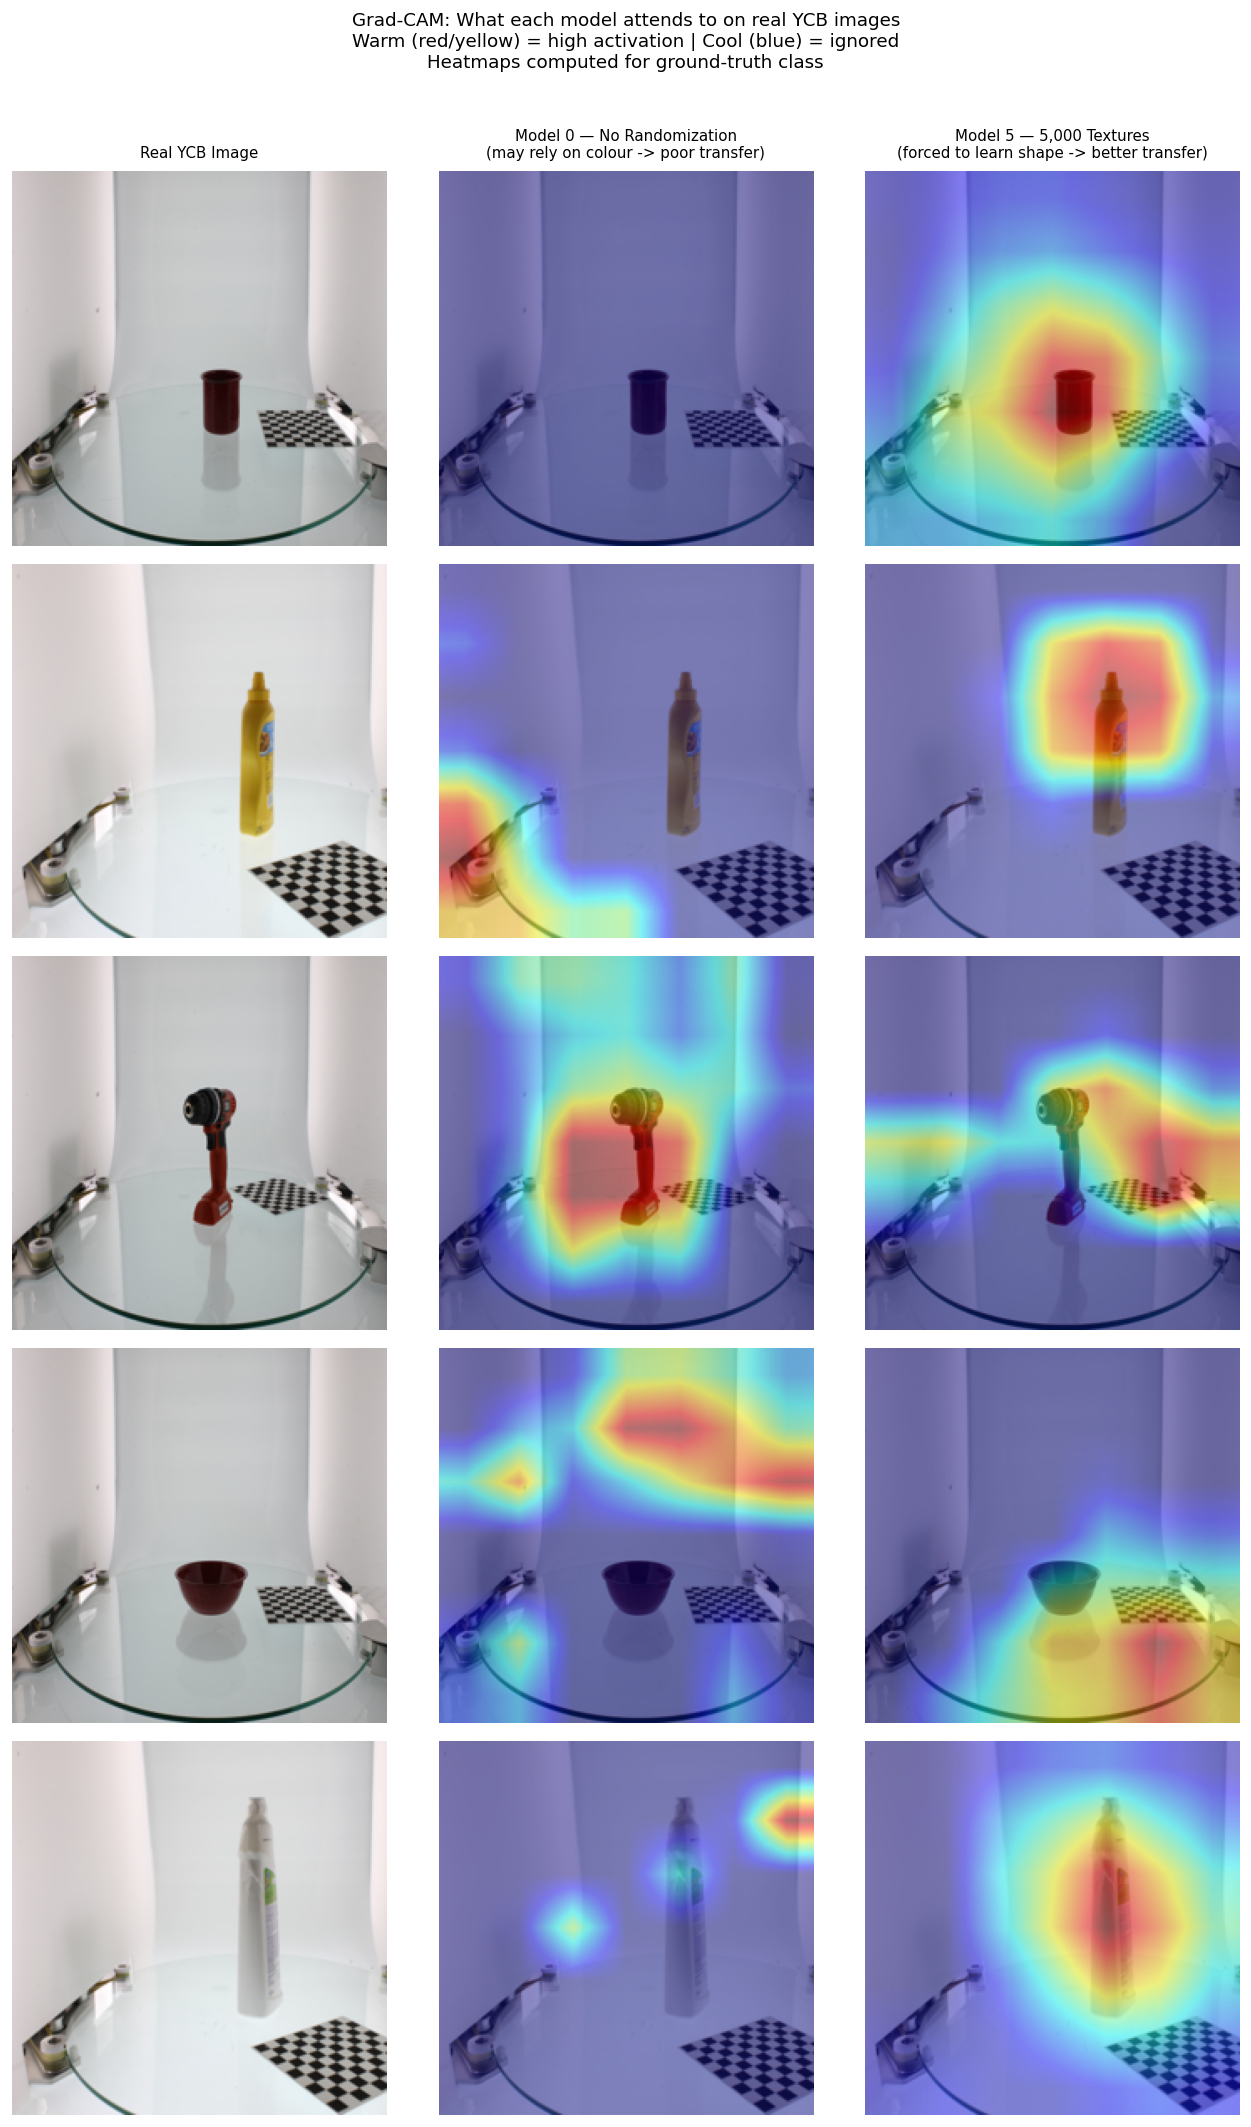

Grad-CAM saved -> C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\results\gradcam_model0_vs_model5.png
Hooks removed OK


In [17]:
# Load both models and attach Grad-CAM hooks
model_0 = load_model_weights(0)
model_5 = load_model_weights(5000)
cam_0   = GradCAM(model_0)
cam_5   = GradCAM(model_5)

# One real test image per class (index 10 — representative, not the very first)
SAMPLE_IDX    = 10
sample_images = []
for class_idx, obj_name in enumerate(OBJECTS):
    imgs = sorted(
        list((RGB_DIR / obj_name).rglob("*.jpg")) +
        list((RGB_DIR / obj_name).rglob("*.JPG"))
    )
    if imgs:
        sample_images.append(
            (imgs[min(SAMPLE_IDX, len(imgs)-1)], class_idx, obj_name)
        )

# ── Figure: 5 rows x 3 columns ────────────────────────────────────────
fig, axes = plt.subplots(len(sample_images), 3,
                         figsize=(11, 3.5 * len(sample_images)))

for col, title in enumerate([
    "Real YCB Image",
    "Model 0 — No Randomization\n(may rely on colour -> poor transfer)",
    "Model 5 — 5,000 Textures\n(forced to learn shape -> better transfer)",
]):
    axes[0, col].set_title(title, fontsize=9, pad=8)

for row, (img_path, true_class, obj_name) in enumerate(sample_images):
    orig_pil = Image.open(img_path).convert("RGB")
    img_t    = test_transform(orig_pil).unsqueeze(0)
    short    = obj_name.split("_", 1)[1].replace("_", " ")

    # Original
    axes[row, 0].imshow(orig_pil.resize((IMG_SIZE, IMG_SIZE)))
    axes[row, 0].set_ylabel(f"Class {true_class}\n{short}",
                            fontsize=8, rotation=90, labelpad=5, va="center")
    axes[row, 0].axis("off")

    # Grad-CAM for both models
    for col, cam_obj in enumerate([cam_0, cam_5], start=1):
        heatmap, pred = cam_obj.generate(img_t.clone(), class_idx=true_class)
        overlay       = overlay_cam(orig_pil, heatmap)
        correct       = pred == true_class
        label         = ("correct" if correct
                         else f"wrong -> {OBJECTS[pred].split('_',1)[1][:12]}")
        axes[row, col].imshow(overlay)
        axes[row, col].set_xlabel(label, fontsize=8,
                                  color="#2A9D8F" if correct else "#E63946")
        axes[row, col].axis("off")

plt.suptitle(
    "Grad-CAM: What each model attends to on real YCB images\n"
    "Warm (red/yellow) = high activation | Cool (blue) = ignored\n"
    "Heatmaps computed for ground-truth class",
    fontsize=11, y=1.01
)
plt.tight_layout()
gradcam_path = RESULTS_DIR / "gradcam_model0_vs_model5.png"
plt.savefig(str(gradcam_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Grad-CAM saved -> {gradcam_path}")

# Always remove hooks after use — stale hooks cause doubled gradients on re-run
cam_0.remove_hooks()
cam_5.remove_hooks()
del model_0, model_5
print("Hooks removed OK")